# Result and Analysis

### Styling tweaks

In [12]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")
base_colors = ["#895798", "#beaed4", "#fdc086", "#386cb0", "#f0027f", "#bf5b17"]
plt.rcParams.update({
    "axes.facecolor": "#0f1115",
    "figure.facecolor": "#0a0c10",
    "axes.edgecolor": "#444",
    "grid.color": "#333",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "axes.prop_cycle": plt.cycler(color=base_colors),
    "font.size": 12,
    "axes.titleweight": "bold",
})


## Experiment Result Fixed Depth

### Performance vs. scale

Looking in: /Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Super_resolution/experiments/experiment_1_constant_depth_3/evaluation
Available runs: ['exp1_depth3_scale0.20_eval', 'exp1_depth3_scale0.30_eval', 'exp1_depth3_scale0.40_eval', 'exp1_depth3_scale0.50_eval', 'exp1_depth3_scale0.60_eval', 'exp1_depth3_scale0.70_eval', 'exp1_depth3_scale0.80_eval', 'exp1_depth3_scale0.90_eval']


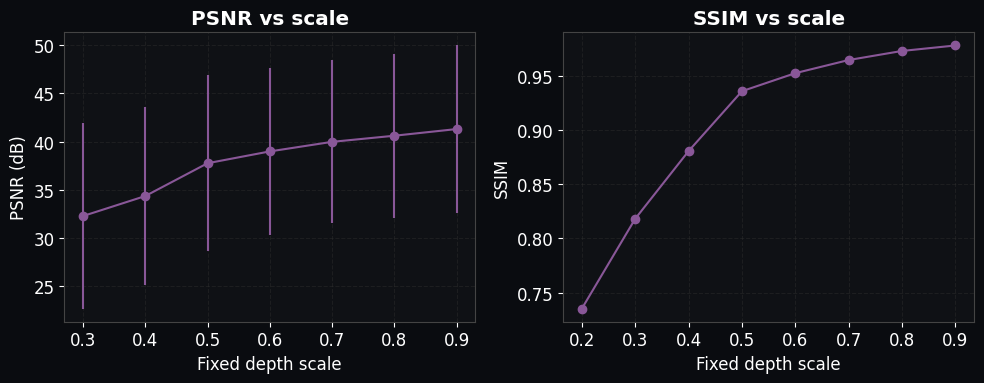

In [13]:
from pathlib import Path
import json, numpy as np, matplotlib.pyplot as plt

project_root = Path.cwd()              # notebook is in Super_resolution/
if not (project_root / "experiments").exists():
    project_root = project_root.parent # fallback if you run from repo root

root = project_root / "experiments" / "experiment_1_constant_depth_3" / "evaluation"
print("Looking in:", root)
print("Available runs:", sorted([p.name for p in root.iterdir() if p.is_dir()]))

scales = ["0.20","0.30","0.40","0.50","0.60","0.70","0.80","0.90"]
metrics = []
for s in scales:
    eval_dir = root / f"exp1_depth3_scale{s}_eval"
    with open(eval_dir / "metrics.json") as f:
        m = json.load(f)
    metrics.append({
        "scale": float(s),
        "psnr": m.get("psnr_mean", np.nan),
        "ssim": m.get("ssim_mean", np.nan),
        "mse": m.get("mse_mean", np.nan),
        "psnr_std": m.get("psnr_std", np.nan),
    })

scales_f = [m["scale"] for m in metrics]
psnr = [m["psnr"] for m in metrics]
ssim = [m["ssim"] for m in metrics]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.errorbar(scales_f, psnr, yerr=[m["psnr_std"] for m in metrics], marker="o")
plt.title("PSNR vs scale"); plt.xlabel("Fixed depth scale"); plt.ylabel("PSNR (dB)")
plt.subplot(1,2,2)
plt.plot(scales_f, ssim, marker="o")
plt.title("SSIM vs scale"); plt.xlabel("Fixed depth scale"); plt.ylabel("SSIM")
plt.tight_layout(); plt.show()


### Training Cost 

In [ ]:
scales = ["0.20","0.30","0.40","0.50","0.60","0.70","0.80","0.90"]
metrics_time = []

for s in scales:
    eval_dir = root / f"exp1_depth3_scale{s}_eval"
    with open(eval_dir / "metrics.json") as f:
        m = json.load(f)
    metrics_time.append({
        "scale": float(s),
        "psnr": m.get("psnr_mean", np.nan),
        "ssim": m.get("ssim_mean", np.nan),
        "mse": m.get("mse_mean", np.nan),
        "psnr_std": m.get("psnr_std", np.nan),
    })

## Experiment Result Adpative Depth

### Performance vs. scale

Looking in: /Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Super_resolution/experiments/experiment_2_adaptive_depth/evaluation
Available runs: ['exp1_depth3_scale0.80_eval', 'exp2_adaptive_depth_scale0.20_eval', 'exp2_adaptive_depth_scale0.30_eval', 'exp2_adaptive_depth_scale0.40_eval', 'exp2_adaptive_depth_scale0.50_eval', 'exp2_adaptive_depth_scale0.60_eval', 'exp2_adaptive_depth_scale0.70_eval']


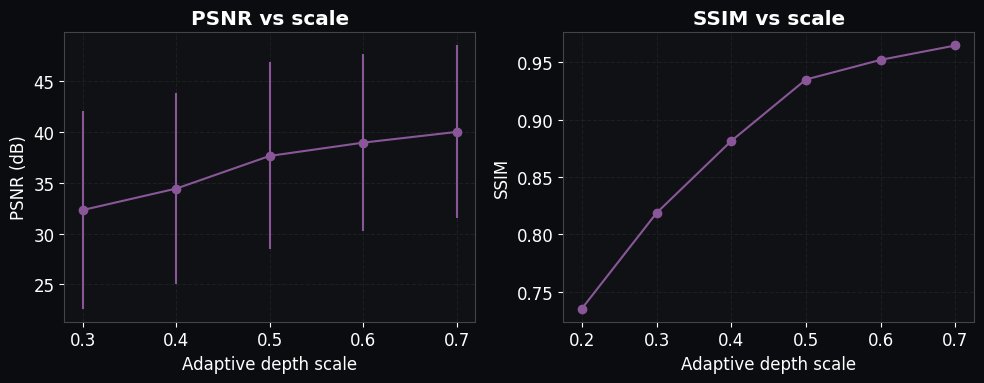

In [15]:
project_root = Path.cwd()
root = project_root / "experiments" / "experiment_2_adaptive_depth" / "evaluation"

# sanity-check the directory
print("Looking in:", root)
print("Available runs:", sorted([p.name for p in root.iterdir() if p.is_dir()]))

scales = ["0.20","0.30","0.40","0.50","0.60","0.70"]
metrics = []
for s in scales:
    eval_dir = root / f"exp2_adaptive_depth_scale{s}_eval"
    with open(eval_dir / "metrics.json") as f:
        m = json.load(f)
    metrics.append({
        "scale": float(s),
        "psnr": m.get("psnr_mean", np.nan),
        "ssim": m.get("ssim_mean", np.nan),
        "mse": m.get("mse_mean", np.nan),
        "psnr_std": m.get("psnr_std", np.nan),
    })

scales_f = [m["scale"] for m in metrics]
psnr = [m["psnr"] for m in metrics]
ssim = [m["ssim"] for m in metrics]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.errorbar(scales_f, psnr, yerr=[m["psnr_std"] for m in metrics], marker="o")
plt.title("PSNR vs scale"); plt.xlabel("Adaptive depth scale"); plt.ylabel("PSNR (dB)")
plt.subplot(1,2,2)
plt.plot(scales_f, ssim, marker="o")
plt.title("SSIM vs scale"); plt.xlabel("Adaptive depth scale"); plt.ylabel("SSIM")
plt.tight_layout(); plt.show()


### Training cost 

   scale  ms_per_step  epoch_duration_s
2    0.2        381.0             206.0
4    0.3        511.0             276.0
5    0.4        498.0             359.0
1    0.5        445.0             481.0
0    0.6        557.0             802.0
6    0.7        895.0            1933.0
3    0.8        977.0            4221.0


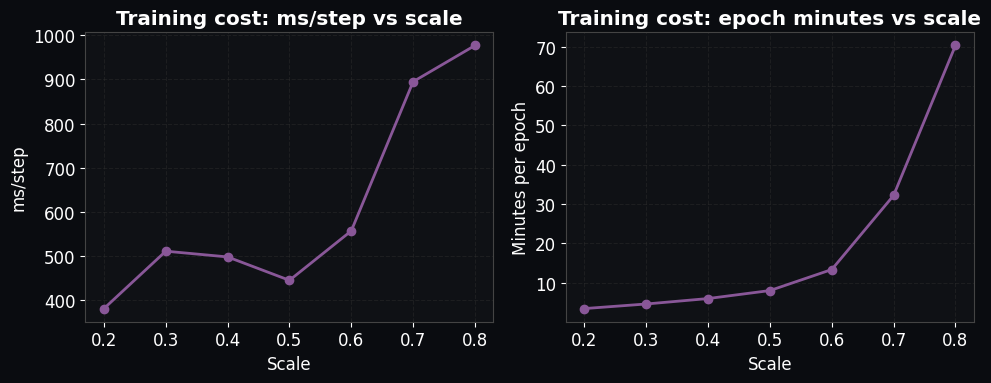

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

project_root = Path.cwd()
if not (project_root / "experiments").exists():
    project_root = project_root.parent

csv_root = project_root / "experiments" / "experiment_2_adaptive_depth" / "csv_logs"

rows = []
for csv_file in csv_root.glob("exp2_adaptive_depth_scale*/epoch_metrics.csv"):
    m = re.search(r"scale([0-9.]+)", csv_file.parent.name)
    if not m:
        continue
    df = pd.read_csv(csv_file)
    rows.append({
        "scale": float(m.group(1)),
        "ms_per_step": df["ms_per_step"].iloc[-1],
        "epoch_duration_s": df["duration_s"].iloc[-1],
    })

time_df = pd.DataFrame(rows).sort_values("scale")
print(time_df)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(time_df["scale"], time_df["ms_per_step"], marker="o", linewidth=2)
plt.title("Training cost: ms/step vs scale")
plt.xlabel("Scale"); plt.ylabel("ms/step")

plt.subplot(1,2,2)
plt.plot(time_df["scale"], time_df["epoch_duration_s"]/60, marker="o", linewidth=2)
plt.title("Training cost: epoch minutes vs scale")
plt.xlabel("Scale"); plt.ylabel("Minutes per epoch")

plt.tight_layout(); plt.show()
